In [5]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Normalization, Lambda, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# =====================================================
# Model 0 (M0): Error vs Non-Error (binary)
# Uses the SAME layout as Model 1 CNN, but with 2 labels:
#   original y in {0,1,2} -> 0 (Non-Error)
#   original y == 3       -> 1 (Error)
# IMPORTANT: Do NOT drop any samples. We remap only.
# =====================================================

# -----------------------------
# Config
# -----------------------------
X_PATH = "../../../data/training/RouterV2.0_training_X.npy"  # (N,4,4)
Y_PATH = "../../../data/training/RouterV2.0_training_y.npy"  # (N,)   labels in {0,1,2,3}

SAVE_PATH = "../../../models/Model0/model0_cnn.keras"

EPOCHS      = 120
BATCH_SIZE  = 128
VAL_SPLIT   = 0.15
LR          = 5e-4
NUM_CLASSES = 2  # 0=Non-Error, 1=Error
SEED = 43
rng = np.random.default_rng(SEED)

# -----------------------------
# Load (NO FILTERING)
# -----------------------------
X = np.load(X_PATH).astype(np.float32)  # (N,4,4)
y_raw = np.load(Y_PATH).astype(np.int64)  # (N,)

assert X.ndim == 3 and X.shape[1:] == (4,4), f"X must be (N,4,4), got {X.shape}"
uniq_raw = set(np.unique(y_raw).tolist())
assert uniq_raw.issubset({0,1,2,3}), f"labels must be in {0,1,2,3}, got {uniq_raw}"

# -----------------------------
# Binary mapping (keep ALL samples)
# -----------------------------
# 0,1,2 -> 0  (Non-Error)
# 3     -> 1  (Error)
y = (y_raw == 3).astype(np.int64)

# Show class balance before/after
print("Raw label distribution:", {int(k): int(v) for k, v in zip(*np.unique(y_raw, return_counts=True))})
print("Binary label distribution (0=Non-Error, 1=Error):", {int(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))})

# Shuffle
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

# -----------------------------
# Normalization (fit on ALL data, as required)
# -----------------------------
norm = Normalization(axis=-1)
norm.adapt(X)

# -----------------------------
# Class weights (handle imbalance automatically)
# -----------------------------
counts = np.bincount(y, minlength=NUM_CLASSES).astype(np.float32)
w = counts.sum() / (counts + 1e-6)
w = (w / w.mean()).tolist()
class_weight = {i: float(wi) for i, wi in enumerate(w)}
print("Class weights (auto):", class_weight)

# -----------------------------
# Model: SAME CNN as Model1 (values + per-step deltas)
# -----------------------------
x_in = Input(shape=(4, 4), name="win")
x_norm = norm(x_in)

def deltas_fn(t):
    d = t[:, 1:, :] - t[:, :-1, :]        # (B,3,4)
    zero = tf.zeros_like(d[:, :1, :])     # (B,1,4)
    return tf.concat([zero, d], axis=1)   # (B,4,4)

deltas = Lambda(deltas_fn, name="deltas", output_shape=(4, 4))(x_in)
x_cat  = Concatenate(axis=-1, name="values_plus_deltas")([x_norm, deltas])  # (B,4,8)

h = Conv1D(64, kernel_size=2, activation='relu', padding='valid')(x_cat)   # -> (B,3,64)
h = Conv1D(128, kernel_size=2, activation='relu', padding='valid')(h)      # -> (B,2,128)
h = Flatten()(h)                                                            # -> (B,256)
h = Dropout(0.3)(h)
h = Dense(128, activation='relu')(h)
h = Dropout(0.2)(h)
out = Dense(NUM_CLASSES, activation='softmax')(h)  # 2-class softmax

model = Model(x_in, out, name="model0_cnn_error_vs_nonerror")
model.compile(optimizer=Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6),
    ],
    verbose=1
)

# -----------------------------
# Save
# -----------------------------
Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
model.save(SAVE_PATH)
print(f"✅ Model saved: {SAVE_PATH}")

# -----------------------------
# Optional: quick sanity check on training set
# -----------------------------
y_prob = model.predict(X, verbose=0)
if y_prob.shape[1] != 2:
    raise ValueError(f"Expected 2 output units, got {y_prob.shape}")
acc = (y_prob.argmax(axis=1) == y).mean()
print(f"Training-set argmax accuracy (for sanity): {acc:.4f}")


Raw label distribution: {0: 8465, 1: 11259, 2: 63775, 3: 153500}
Binary label distribution (0=Non-Error, 1=Error): {0: 83499, 1: 153500}
Class weights (auto): {0: 1.2953641414642334, 1: 0.7046359181404114}
Epoch 1/120
1574/1574 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5069 - loss: 9.8749 - val_accuracy: 0.4515 - val_loss: 0.6945 - learning_rate: 5.0000e-04
Epoch 2/120
1574/1574 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4405 - loss: 0.6187 - val_accuracy: 0.4448 - val_loss: 0.6549 - learning_rate: 5.0000e-04
Epoch 3/120
1574/1574 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4400 - loss: 0.6028 - val_accuracy: 0.4327 - val_loss: 0.6460 - learning_rate: 5.0000e-04
Epoch 4/120
1574/1574 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4440 - loss: 0.6005 - val_accuracy: 0.4567 - val_loss: 0.6573 - learning_rate: 5.0000e-04
Epoch 5/120
1574/1574 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4745 - loss: 0.5902 - val_accuracy: 0.5495 - val_loss: 0.6278 - learning_rate: 5.0000e-04

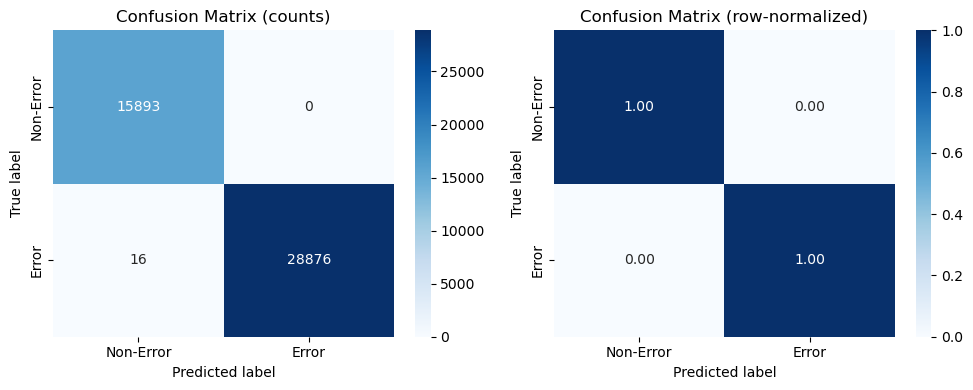

Accuracy: 0.9996
              precision    recall  f1-score   support

   Non-Error      0.999     1.000     0.999     15893
       Error      1.000     0.999     1.000     28892

    accuracy                          1.000     44785
   macro avg      0.999     1.000     1.000     44785
weighted avg      1.000     1.000     1.000     44785



In [6]:

# ==== EVAL: Confusion matrix & report for Model 0 (Error vs Non-Error) ====
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras

# Optional seaborn; fallback to matplotlib if unavailable
try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

# =========================
# Config
# =========================
TEST_SOURCE = "v2"  # choose "legacy" if needed

# Paths (legacy)
X_PATH_ROUTER_TEST     = "../../../data/test/Router_test_X.npy"
Y_PATH_ROUTER_TEST     = "../../../data/test/Router_test_y.npy"
X_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_X.npy"
Y_PATH_ROUTER_OCC_TEST = "../../../data/test/RouterOCC_test_y.npy"

# Paths (V2.0)
X_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_X.npy"
Y_PATH_ROUTER_V2_TEST  = "../../../data/test/RouterV2.0_test_y.npy"

# Binary label space for M0
LABELS = [0, 1]
NAMES  = ["Non-Error", "Error"]

# -----------------------------
# Re-declare the Lambda used during training (must match exactly)
# -----------------------------
def deltas_fn(t):
    d = t[:, 1:, :] - t[:, :-1, :]        # (B,3,4)
    zero = tf.zeros_like(d[:, :1, :])     # (B,1,4)
    return tf.concat([zero, d], axis=1)   # (B,4,4)

# -----------------------------
# Load model
# -----------------------------
MODEL0_PATH = "../../../models/Model0/model0_cnn.keras"
model = keras.models.load_model(
    MODEL0_PATH,
    custom_objects={'deltas_fn': deltas_fn}
)

# -----------------------------
# Load test data
# -----------------------------
def _np_load(path, astype=None):
    if not os.path.exists(path):
        return None
    arr = np.load(path, allow_pickle=True)
    if astype is not None:
        arr = arr.astype(astype)
    return arr

def load_test_split(test_source="v2"):
    if test_source == "v2":
        X = _np_load(X_PATH_ROUTER_V2_TEST, np.float32)
        y = _np_load(Y_PATH_ROUTER_V2_TEST, np.int64)
        if X is None or y is None:
            raise FileNotFoundError("RouterV2.0 test split not found.")
        return X, y
    elif test_source == "legacy":
        X1 = _np_load(X_PATH_ROUTER_TEST, np.float32)
        y1 = _np_load(Y_PATH_ROUTER_TEST, np.int64)
        if X1 is None or y1 is None:
            raise FileNotFoundError("Legacy Router_test split not found.")
        X2 = _np_load(X_PATH_ROUTER_OCC_TEST, np.float32)
        y2 = _np_load(Y_PATH_ROUTER_OCC_TEST, np.int64)
        if X2 is not None and y2 is not None:
            X = np.concatenate([X1, X2], axis=0)
            y = np.concatenate([y1, y2], axis=0)
        else:
            X, y = X1, y1
        return X, y
    else:
        raise ValueError("Invalid TEST_SOURCE. Use 'v2' or 'legacy'.")

X_test, y_true_raw = load_test_split(TEST_SOURCE)

if X_test.ndim != 3 or X_test.shape[1:] != (4, 4):
    raise ValueError(f"X_test shape must be (N,4,4); got {X_test.shape}")

# Map to binary: {0,1,2}->0 Non-Error, {3}->1 Error
y_true = (y_true_raw == 3).astype(np.int64)

# -----------------------------
# Predict
# -----------------------------
y_prob = model.predict(X_test, verbose=0)
if y_prob.ndim != 2 or y_prob.shape[1] != len(LABELS):
    raise ValueError(f"model.predict output must be (N, {len(LABELS)}); got {y_prob.shape}")
y_pred = y_prob.argmax(axis=1)

# -----------------------------
# Confusion matrices
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
row_sums = cm.sum(axis=1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = np.divide(cm.astype(np.float32), row_sums, where=(row_sums != 0))
    cm_norm = np.nan_to_num(cm_norm, nan=0.0, posinf=0.0, neginf=0.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

def _plot_mat(mat, ax_, title, fmt, is_norm=False):
    if _HAS_SNS:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=NAMES, yticklabels=NAMES, ax=ax_,
                    vmin=0.0 if is_norm else None, vmax=1.0 if is_norm else None)
    else:
        im = ax_.imshow(mat, aspect="auto", interpolation="nearest")
        ax_.set_xticks(range(len(NAMES))); ax_.set_yticks(range(len(NAMES)))
        ax_.set_xticklabels(NAMES, rotation=45, ha="right")
        ax_.set_yticklabels(NAMES)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax_.text(j, i, (f"{mat[i,j]:.2f}" if is_norm else f"{int(mat[i,j])}"),
                         ha="center", va="center")
        fig.colorbar(im, ax=ax_)
    ax_.set_title(title)
    ax_.set_xlabel("Predicted label"); ax_.set_ylabel("True label")

_plot_mat(cm,      ax[0], "Confusion Matrix (counts)",       "d",   is_norm=False)
_plot_mat(cm_norm, ax[1], "Confusion Matrix (row-normalized)",".2f", is_norm=True)

plt.tight_layout()
plt.show()

# -----------------------------
# Metrics
# -----------------------------
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, labels=LABELS, target_names=NAMES, digits=3))
